In [1]:
import os
if 'PATH_SET' not in locals():
    os.chdir('..')
    PATH_SET = True

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle.mplstyle')

import torch
from torch import distributions as dist
import zuko

from tqdm.autonotebook import tqdm

import imageio.v3 as iio

/tmp/ipykernel_225128/2761719794.py:17: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
im_values = iio.imread('data/geographic_data/surface_displacement_landslide_clean.png')

def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140])

im_values = rgb2gray(im_values)

In [3]:
MIN_EASTING = 2701200.0
MAX_EASTING = 2703700.0

MIN_NORTHING = 1171500.0
MAX_NORTHING = 1174500.0

im_x_min = 2701250 - MIN_EASTING
im_x_max = 2703250 - MIN_EASTING

im_y_min = 1171500 - MIN_NORTHING
im_y_max = 1174050 - MIN_NORTHING

In [4]:
im_ds = xr.DataArray(
    im_values[::-1], dims=['y', 'x'],
    coords={'x': np.linspace(im_x_min, im_x_max, im_values.shape[1]),
            'y': np.linspace(im_y_min, im_y_max, im_values.shape[0])})

im_ds_raw = (im_ds - im_ds.min()) / (im_ds.max() - im_ds.min())

# smooth image with gaussian filter
from scipy.ndimage import gaussian_filter
im_ds.data = gaussian_filter(im_ds_raw.data, sigma=25)


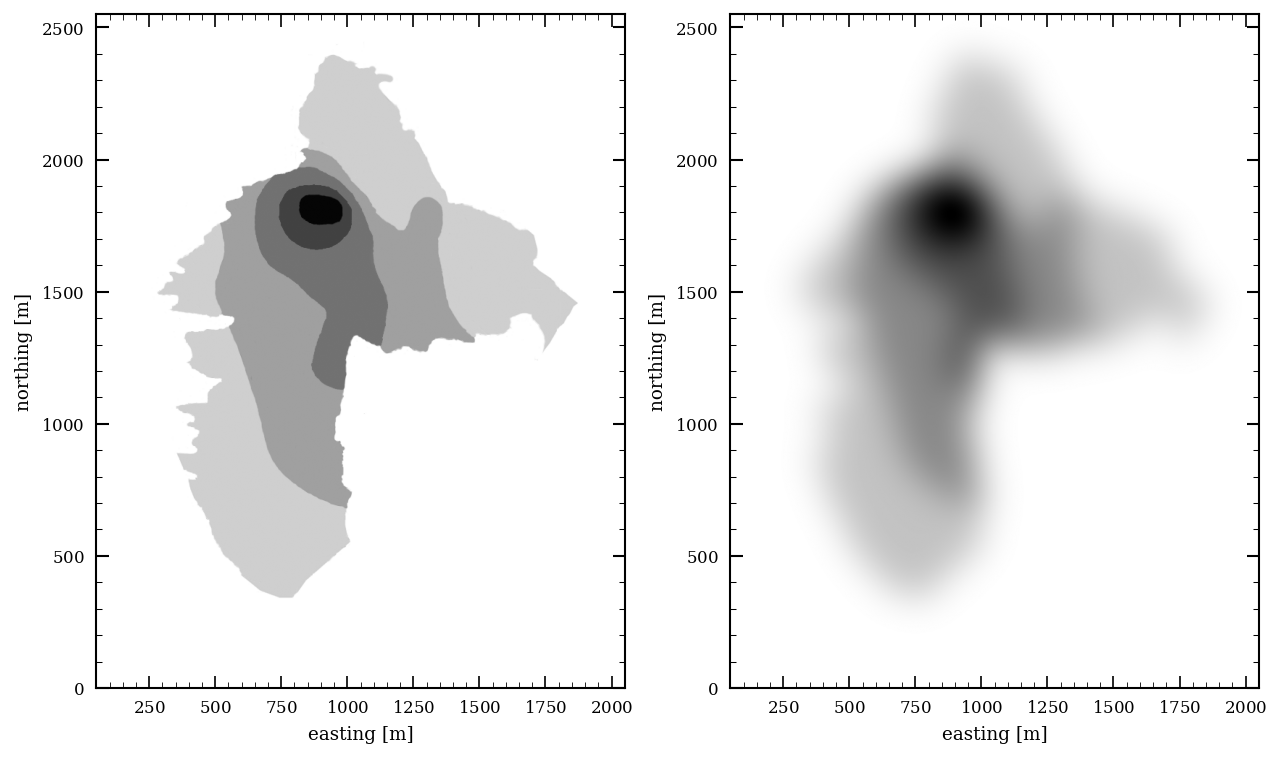

In [5]:
fig, ax_dict = plt.subplot_mosaic([['raw', 'smooth']], figsize=(10, 10))

ax = ax_dict['raw']

im = ax.imshow(im_ds_raw, origin='lower', cmap='gray', extent=[im_x_min, im_x_max, im_y_min, im_y_max])

ax = ax_dict['smooth']

im = ax.imshow(im_ds, origin='lower', cmap='gray', extent=[im_x_min, im_x_max, im_y_min, im_y_max])

for ax in ax_dict.values():
    ax.set_aspect('equal')

    ax.set_xlabel('easting [m]')
    ax.set_ylabel('northing [m]')

# fig.colorbar(im, label='Surface displacement [m]')

plt.show()

In [6]:
from helpers.distributions import Empirical

X, Y = np.meshgrid(im_ds.x.values, im_ds.y.values)

X = X.flatten()
Y = Y.flatten()
coords = np.vstack((X, Y)).T

Z = 1 - im_ds.values.flatten()

emperical_dist = Empirical(
    torch.from_numpy(coords),
    torch.from_numpy(Z).log(),
    )

torch.manual_seed(0)
empirical_samples = emperical_dist.sample((100000,)).float()

In [7]:
# fig, ax = plt.subplots(figsize=(4, 4))

# im = ax.imshow(im_ds, origin='lower', cmap='gray', extent=[im_x_min, im_x_max, im_y_min, im_y_max])
# ax.scatter(empirical_samples[:10000, 0], empirical_samples[:10000, 1], s=0.1, c='b', alpha=0.2)

# plt.show()

# Kernel Density Estimation

In [8]:
class KDE(dist.Distribution):
    def __init__(self, samples, bandwidth):
        self.samples = samples
        self.bandwidth = torch.sqrt(torch.tensor(bandwidth))

        self._kde = zuko.flows.GMM(
            features=samples.shape[-1],
            components=samples.shape[0],
            buffer=True
        )
                        
        self._kde.phi[0].data = torch.ones_like(self._kde.phi[0].data)
        self._kde.phi[1].data = self.samples
        self._kde.phi[2].data = torch.ones_like(self._kde.phi[2].data)*self.bandwidth
        self._kde.phi[3].data = torch.zeros_like(self._kde.phi[3].data)
        
    def log_prob(self, x):
        return self._kde.forward().log_prob(x)
    
    def sample(self, sample_shape=torch.Size()):
        return self._kde.forward().sample(sample_shape)
    
    def rsample(self, sample_shape=torch.Size()):
        return self._kde.forward().rsample(sample_shape)
    
kde_dist = KDE(empirical_samples[:10000], 20)

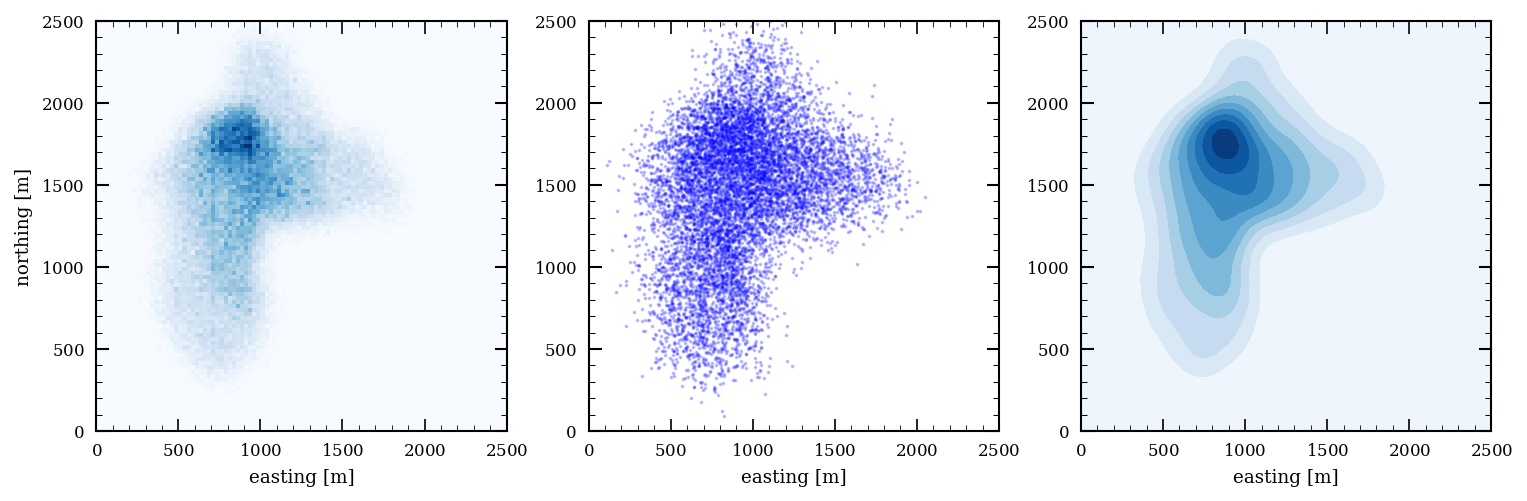

In [9]:
fig, ax_dict = plt.subplot_mosaic(
    [['A', 'B', 'C']], figsize=(12, 4),
    # sharex=True, sharey=True,
    subplot_kw={'aspect': 'equal'})

ax = ax_dict['A']

ax.hist2d(empirical_samples[:, 0], empirical_samples[:, 1], bins=100, cmap='Blues', range=[[0, 2500], [0, 2500]])

ax.set_ylabel('northing [m]')

ax = ax_dict['B']

kde_samples = kde_dist.sample((10000,)).float()
ax.scatter(kde_samples[:, 0], kde_samples[:, 1], s=1, c='b', alpha=0.2)

ax = ax_dict['C']

X, Y = torch.meshgrid(torch.linspace(0, 2500, 100), torch.linspace(0, 2500, 100), indexing='ij')
coords = torch.stack((X.flatten(), Y.flatten()), dim=-1)
Z_flow = kde_dist.log_prob(coords).exp().reshape(100, 100).detach().numpy()
ax.contourf(X, Y, Z_flow, levels=10, cmap='Blues')

for ax in ax_dict.values():
    ax.set_xlim(0, 2500)
    ax.set_ylim(0, 2500)
    ax.set_xlabel('easting [m]')

plt.show()

In [10]:
test_model = torch.tensor([[1500.0, 1500.0]]).float().requires_grad_(True)
test_log_prob = kde_dist.log_prob(test_model)

print(test_log_prob)

prior_hessian = torch.autograd.functional.hessian(
    kde_dist.log_prob, test_model).squeeze()

tensor([-14.5616], grad_fn=<LogsumexpBackward0>)


In [11]:
# for i in tqdm(range(1000)):
#     prior_hessian = torch.autograd.functional.hessian(
#         kde_dist.log_prob, test_model).squeeze()

#     # print(prior_hessian)

# Normalizing Flows

Training:   0%|          | 0/2000 [00:00<?, ?it/s]

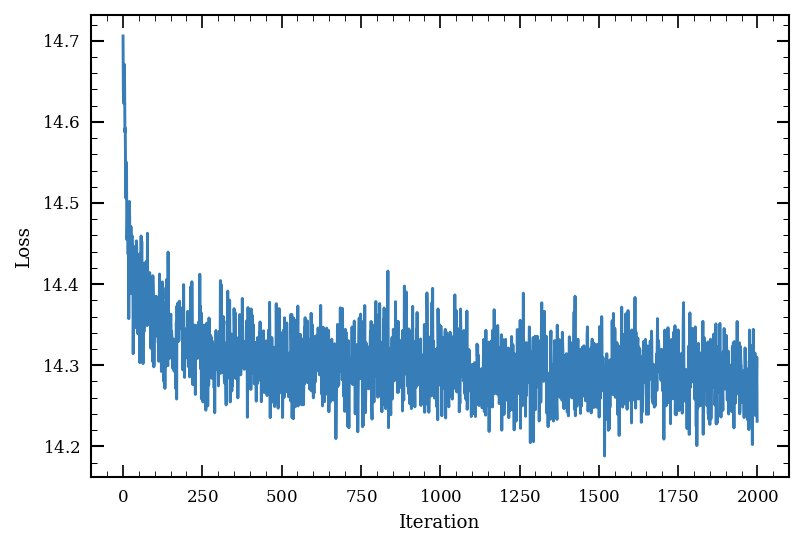

In [13]:
import os
file_name = 'data/priors/surface_displacement_prior.pt'

if os.path.exists(file_name):
    flow = torch.load(file_name, map_location='cpu', weights_only=False)

else:
    torch.manual_seed(0)
    flow = zuko.flows.MAF(coords.shape[1], transforms=8)

    coords_means = empirical_samples.mean(dim=0)
    coords_std   = empirical_samples.std(dim=0)

    flow.transform.transforms.insert(0,
        zuko.lazy.UnconditionalTransform(
            dist.AffineTransform, -coords_means/coords_std, 1/coords_std, buffer=True)
    )
    optimizer = torch.optim.Adam(flow.parameters(), lr=1e-4)

    N_iter = 2000
    batch_size = 512

    losses = []

    for i in (pbar:= tqdm(range(N_iter), total=N_iter, desc='Training')):

        sample_batch = emperical_dist.sample((batch_size,)).to(torch.float32).detach()
        
        # print(sample_batch)
        
        # print(-flow.forward().sample((5,)))

        # print()
        
        optimizer.zero_grad()
        loss = -flow.forward().log_prob(sample_batch).mean()
        loss.backward()
        optimizer.step()
        if i % 100 == 0:
            pbar.set_postfix({'loss': loss.item()})
        
        losses.append(loss.item())

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(losses)

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')

    plt.show()
    
    torch.save(flow, file_name)


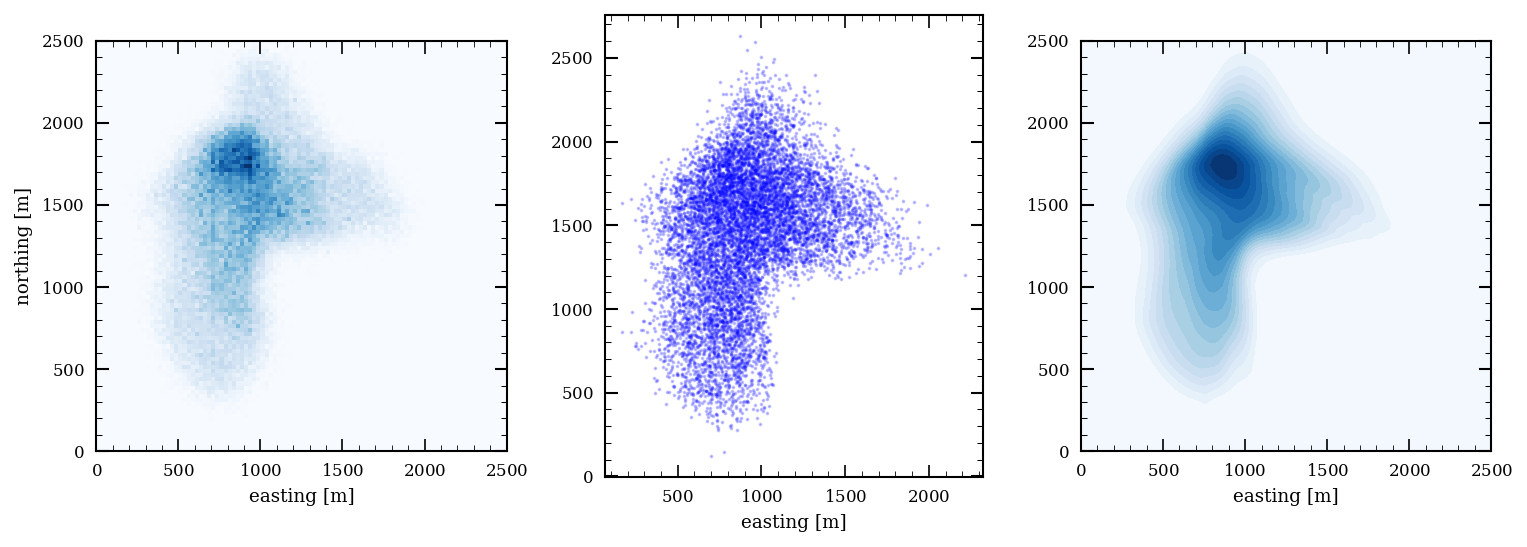

In [14]:
fig, ax_dict = plt.subplot_mosaic(
    [['A', 'B', 'C']], figsize=(12, 4),
    # sharex=True, sharey=True,
    subplot_kw={'aspect': 'equal'})

ax = ax_dict['A']

ax.hist2d(empirical_samples[:, 0], empirical_samples[:, 1], bins=100, cmap='Blues', range=[[0, 2500], [0, 2500]])

ax.set_ylabel('northing [m]')

ax = ax_dict['B']

kde_samples = flow.forward().sample((10000,)).float()
ax.scatter(kde_samples[:, 0], kde_samples[:, 1], s=1, c='b', alpha=0.2)

ax = ax_dict['C']

X, Y = torch.meshgrid(torch.linspace(0, 2500, 100), torch.linspace(0, 2500, 100), indexing='ij')
coords = torch.stack((X.flatten(), Y.flatten()), dim=-1)
Z_flow = flow.forward().log_prob(coords).exp().reshape(100, 100).detach().numpy()
ax.contourf(X, Y, Z_flow, levels=20, cmap='Blues')

for ax in ax_dict.values():
    ax.set_xlabel('easting [m]')

plt.show()

In [ ]:
test_model = torch.tensor([[1500.0, 1500.0]]).float().requires_grad_(True)
test_log_prob = flow.forward().log_prob(test_model)

print(test_log_prob)

prior_hessian = torch.autograd.functional.hessian(
    flow.forward().log_prob, test_model).squeeze()

tensor([-14.6021], grad_fn=<AddBackward0>)


In [ ]:
# for i in tqdm(range(100)):
#     prior_hessian = torch.autograd.functional.hessian(
#         flow.forward().log_prob, test_model).squeeze()

#     # print(prior_hessian)